# Notebook 9 — Charge marémotrique : tendance et conclusion

**Questions de Roxane :**
1. Est-ce que la variation de σ_n change l'**émergence du chaos** ?
2. Est-ce que ça change la **périodicité** ?

**Approche :**
- Sweep δ ∈ {0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40} — 8 amplitudes
- 3 réalisations par δ (conditions initiales légèrement différentes) → ~45–60 événements par δ
- T = 2000, burn-in = 500 → ~1500 unités analysées
- Métriques quantitatives :
  - **Taux d'événements** et **CoV des intervalles de récurrence** (périodicité)
  - **Test de Rayleigh** sur la distribution de phase (corrélation marée/sismicité)
  - **Exposant de Lyapunov** Λ(δ) pour δ ∈ {0, 0.15, 0.30, 0.40} (chaos)

**Note sur T_tide :** T_tide = 50, T_rec ≈ 100 (estimé sur δ=0) → ratio T_tide/T_rec ≈ 0.5.
La marée oscille environ 2× plus vite que le cycle sismique naturel.

**Paramètres :** N=20, ε=0.5, γ_μ=0.5, γ_λ=√0.2, ξ=0.5, f̄=3.2, slip law.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
import gc

GM   = 0.5;  GL  = np.sqrt(0.2); XI  = 0.5
EPS  = 0.5;  FBAR = 3.2;         N   = 20
T_TIDE  = 50.0
T_SIM   = 2000
T_BURN  = 500
GM2 = GM**2;  GL2 = GL**2
EPS1 = 1.0 + EPS

DELTA_LIST = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40]
N_REAL     = 3    # réalisations par δ
SEEDS      = [0, 42, 137]

print(f"T_tide={T_TIDE}, T_sim={T_SIM}, burn={T_BURN}")
print(f"δ values: {DELTA_LIST}")
print(f"Realisations: {N_REAL}, seeds: {SEEDS}")

T_tide=50.0, T_sim=2000, burn=500
δ values: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]
Réalisations: 3, seeds: [0, 42, 137]


---
## 1 — Modèle et simulation

In [2]:
def make_rhs_tidal(delta, T_tide=T_TIDE):
    def rhs(t, y):
        u=y[:N]; v=y[N:2*N]; Th=y[2*N:3*N]; dy=np.empty(3*N)
        lap=np.empty(N)
        lap[0]=u[1]-u[0]; lap[1:-1]=u[:-2]-2*u[1:-1]+u[2:]; lap[-1]=u[-2]-u[-1]
        vp1=np.maximum(v+1,1e-30); lv=np.log(vp1)
        xi_eff = XI/(1.0+delta*np.sin(2*np.pi*t/T_tide)) if delta!=0 else XI
        dy[:N]=v
        dy[N:2*N]=GM2*lap - GL2*u - (GM2/xi_eff)*(FBAR+Th+lv)
        dy[2*N:3*N]=-vp1*(Th+EPS1*lv)   # slip law
        return dy
    return rhs

def make_ic(seed=0):
    rng = np.random.default_rng(seed)
    u0  = -FBAR*GM2/(XI*GL2)
    xb  = (np.arange(1,N+1)-0.5)*(20./N)
    u_i = u0 + np.exp(-(xb-10)**2) + rng.normal(0, 1e-4, N)
    return np.concatenate([u_i, np.zeros(N), np.zeros(N)])

def simulate(delta, seed=0, T=T_SIM):
    rhs = make_rhs_tidal(delta)
    y0  = make_ic(seed)
    sol = solve_ivp(rhs, [0,T], y0, method='Radau',
                    rtol=1e-7, atol=1e-9, max_step=0.5, dense_output=False)
    t = sol.t; v = sol.y[N:2*N,:].T
    return t, v

print("Functions defined.")

Fonctions définies.


---
## 2 — Détection d'événements et métriques

In [3]:
def detect_events(t, v, t_burn=T_BURN, v_thresh=1.5, min_gap=5.0):
    """Retourne les temps des events after burn-in."""
    mask = t >= t_burn
    t_m  = t[mask]; v_m  = v[mask,:]
    vmax = v_m.max(axis=1); above = vmax > v_thresh
    t_events = []; t_last = -np.inf
    for i in range(1, len(above)):
        if above[i] and not above[i-1] and (t_m[i]-t_last) >= min_gap:
            t_events.append(t_m[i]); t_last = t_m[i]
    return np.array(t_events)

def tidal_phase(t_events, T_tide=T_TIDE):
    """Tidal phase en radians ∈ [0, 2π] au moment de chaque event."""
    return (2*np.pi * (t_events % T_tide) / T_tide)

def rayleigh_test(phases):
    """
    Rayleigh test for uniform phase distribution.
    Returns (R, p_value) where R ∈ [0,1] et p_value teste H0: distribution uniforme.
    Formule exacte : Zar (1999), Biostatistical Analysis, §26.5
    """
    n = len(phases)
    if n < 3:
        return np.nan, np.nan
    C = np.mean(np.cos(phases)); S = np.mean(np.sin(phases))
    R = np.sqrt(C**2 + S**2)           # longueur du resultant vector moyen
    Z = n * R**2                        # statistique de test
    # Approximation de la p-value (Zar 1999, eq. 26.12)
    p = np.exp(-Z) * (1 + (2*Z - Z**2)/(4*n) - (24*Z - 132*Z**2 + 76*Z**3 - 9*Z**4)/(288*n**2))
    p = np.clip(p, 0, 1)
    mean_phase = np.arctan2(S, C) % (2*np.pi)
    return R, float(p), float(mean_phase)

print("Metric functions defined.")

Fonctions métriques définies.


---
## 3 — Sweep δ : statistiques sur N_REAL réalisations

In [4]:
results = {d: {'t_events_all': [], 'intervals_all': []} for d in DELTA_LIST}

for delta in DELTA_LIST:
    print(f"\nδ = {delta:.2f}")
    for seed in SEEDS:
        print(f"  seed={seed}...", end=' ', flush=True)
        t, v = simulate(delta, seed=seed)
        t_ev = detect_events(t, v)
        print(f"{len(t_ev)} events")
        results[delta]['t_events_all'].extend(t_ev.tolist())
        if len(t_ev) >= 2:
            results[delta]['intervals_all'].extend(np.diff(t_ev).tolist())

# Compute summary statistics
summary = {}
for delta in DELTA_LIST:
    t_ev  = np.array(results[delta]['t_events_all'])
    ints  = np.array(results[delta]['intervals_all'])
    n     = len(t_ev)
    T_anal = N_REAL * (T_SIM - T_BURN)

    rate  = n / T_anal
    CoV   = (np.std(ints) / np.mean(ints)) if len(ints) >= 2 else np.nan
    phases = tidal_phase(t_ev) if n >= 3 else np.array([])
    R, pval, mean_ph = rayleigh_test(phases) if n >= 3 else (np.nan, np.nan, np.nan)

    summary[delta] = {'n': n, 'rate': rate, 'CoV': CoV,
                      'R': R, 'pval': pval, 'mean_phase': mean_ph,
                      'phases': phases, 'intervals': ints}
    print(f"δ={delta:.2f}: n={n}, rate={rate:.3f}, CoV={CoV:.3f}, "
          f"R={R:.3f}, p={pval:.3f}, mean_phase={np.degrees(mean_ph):.0f}°")

print("\nSweep complete.")


δ = 0.00
  seed=0... 99 events
  seed=42... 109 events
  seed=137... 104 events

δ = 0.05
  seed=0... 107 events
  seed=42... 97 events
  seed=137... 105 events

δ = 0.10
  seed=0... 113 events
  seed=42... 108 events
  seed=137... 97 events

δ = 0.15
  seed=0... 99 events
  seed=42... 103 events
  seed=137... 93 events

δ = 0.20
  seed=0... 98 events
  seed=42... 85 events
  seed=137... 88 events

δ = 0.25
  seed=0... 95 events
  seed=42... 84 events
  seed=137... 89 events

δ = 0.30
  seed=0... 85 events
  seed=42... 82 events
  seed=137... 79 events

δ = 0.40
  seed=0... 69 events
  seed=42... 69 events
  seed=137... 75 events
δ=0.00: n=312, rate=0.069, CoV=0.396, R=0.035, p=0.678, mean_phase=214°
δ=0.05: n=309, rate=0.069, CoV=0.429, R=0.037, p=0.648, mean_phase=21°
δ=0.10: n=318, rate=0.071, CoV=0.423, R=0.083, p=0.109, mean_phase=73°
δ=0.15: n=295, rate=0.066, CoV=0.398, R=0.087, p=0.109, mean_phase=114°
δ=0.20: n=271, rate=0.060, CoV=0.441, R=0.124, p=0.015, mean_phase=124°
δ=0

---
## 4 — Figure synthèse : tendances vs δ

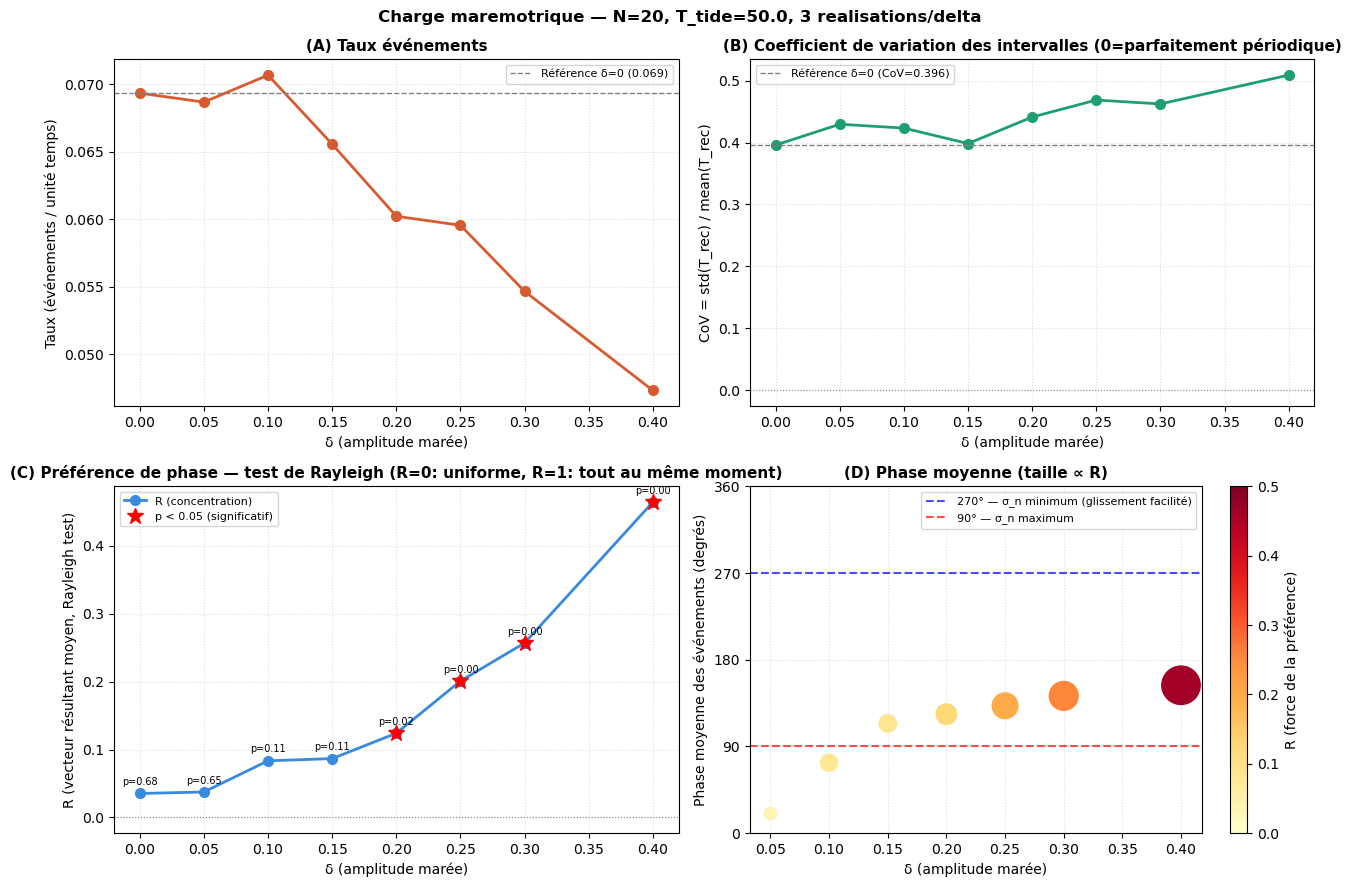

Figure → nb9_tidal_summary.png


In [9]:
deltas = np.array(DELTA_LIST)
rates  = np.array([summary[d]['rate']  for d in DELTA_LIST])
CoVs   = np.array([summary[d]['CoV']   for d in DELTA_LIST])
Rs     = np.array([summary[d]['R']     for d in DELTA_LIST])
pvals  = np.array([summary[d]['pval']  for d in DELTA_LIST])
mphase = np.array([np.degrees(summary[d]['mean_phase']) for d in DELTA_LIST])
ns     = np.array([summary[d]['n']     for d in DELTA_LIST])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    f'Charge maremotrique — N={N}, T_tide={T_TIDE}, {N_REAL} realisations/delta',
    fontsize=12, fontweight='bold')

# ── (A) Event rate ────────────────────────────────────────────────────
ax = axes[0,0]
ax.plot(deltas, rates, 'o-', color='#D85A30', lw=2, ms=7)
ax.axhline(rates[0], color='gray', ls='--', lw=1, label=f'Reference δ=0 ({rates[0]:.3f})')
ax.set_xlabel('δ (tidal amplitude)', fontsize=10)
ax.set_ylabel('Rate (events / time unit)', fontsize=10)
ax.set_title('(A) Taux events', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, ls=':', alpha=0.4)

# ── (B) CoV of intervals de récurrence ─────────────────────────────────────
ax = axes[0,1]
ax.plot(deltas, CoVs, 'o-', color='#1D9E75', lw=2, ms=7)
ax.axhline(CoVs[0], color='gray', ls='--', lw=1, label=f'Reference δ=0 (CoV={CoVs[0]:.3f})')
ax.axhline(0, color='black', ls=':', lw=0.8, alpha=0.4)
ax.set_xlabel('δ (tidal amplitude)', fontsize=10)
ax.set_ylabel('CoV = std(T_rec) / mean(T_rec)', fontsize=10)
ax.set_title('(B) Coefficient of variation des intervalles (0=parfaitement periodic)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, ls=':', alpha=0.4)

# ── (C) Statistique de Rayleigh R ────────────────────────────────────────────
ax = axes[1,0]
ax.plot(deltas, Rs, 'o-', color='#378ADD', lw=2, ms=7, label='R (concentration)')
ax.axhline(0, color='gray', ls=':', lw=0.8)
# Marquer les δ avec p < 0.05 (significatif)
sig_mask = pvals < 0.05
if sig_mask.any():
    ax.plot(deltas[sig_mask], Rs[sig_mask], '*', color='red', ms=12,
            label='p < 0.05 (significatif)')
ax.set_xlabel('δ (tidal amplitude)', fontsize=10)
ax.set_ylabel('R (mean resultant vector, Rayleigh test)', fontsize=10)
ax.set_title('(C) Phase preference — Rayleigh test (R=0: uniform, R=1: fully concentratedent)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, ls=':', alpha=0.4)
# Annoter les p-values
for d, R, p in zip(deltas, Rs, pvals):
    ax.annotate(f'p={p:.2f}', (d, R), textcoords='offset points',
                xytext=(0, 6), fontsize=7, ha='center')

# ── (D) Mean phase des events ─────────────────────────────────────────
ax = axes[1,1]
ax.scatter(deltas[1:], mphase[1:], s=80*Rs[1:]*20+20,
           c=Rs[1:], cmap='YlOrRd', vmin=0, vmax=0.5, zorder=3)
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(0, 0.5))
plt.colorbar(sm, ax=ax, label='R (force de la preference)')
ax.axhline(270, color='blue', ls='--', lw=1.5, alpha=0.7,
           label='270° — σ_n minimum (slip facilitated)')
ax.axhline(90,  color='red', ls='--', lw=1.5, alpha=0.7,
           label='90° — σ_n maximum')
ax.set_xlabel('δ (tidal amplitude)', fontsize=10)
ax.set_ylabel('Mean triggering phase (degrees)', fontsize=10)
ax.set_ylim(0, 360); ax.set_yticks([0,90,180,270,360])
ax.set_title('(D) Mean phase (taille ∝ R)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, ls=':', alpha=0.4)

plt.tight_layout()
plt.savefig('nb9_tidal_summary.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure → nb9_tidal_summary.png")

---
## 5 — Diagrammes en rose par δ

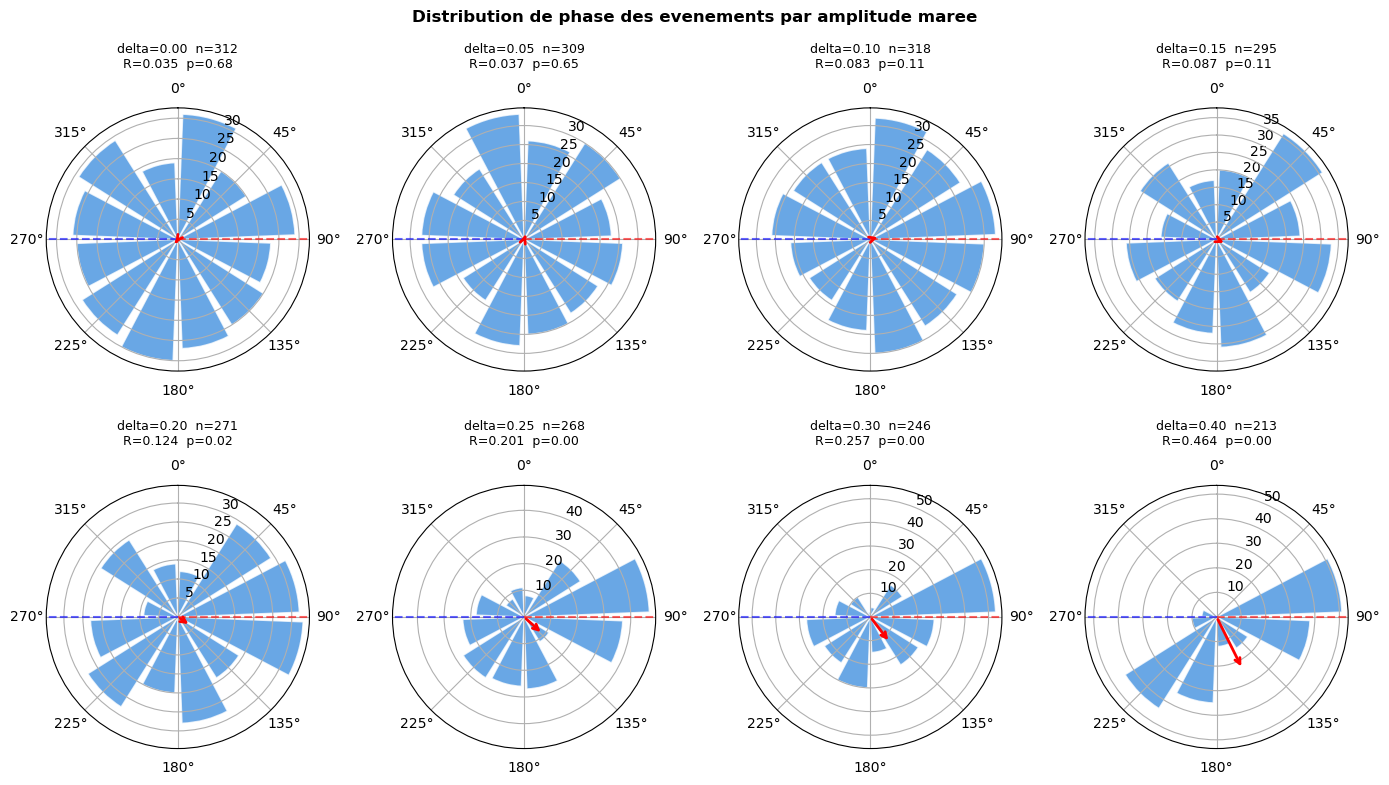

Figure → nb9_rose_diagrams.png


In [10]:
n_cols = 4
n_rows = int(np.ceil(len(DELTA_LIST) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                          subplot_kw={'projection': 'polar'},
                          figsize=(14, 4*n_rows))
fig.suptitle('Distribution de phase des evenements par amplitude maree',
             fontsize=12, fontweight='bold')

axes_flat = axes.flatten()
bins = np.linspace(0, 2*np.pi, 13)   # 12 bins de 30°

for i, delta in enumerate(DELTA_LIST):
    ax  = axes_flat[i]
    phs = summary[delta]['phases']
    n   = summary[delta]['n']
    R   = summary[delta]['R']
    p   = summary[delta]['pval']

    if len(phs) > 0:
        counts, _ = np.histogram(phs, bins=bins)
        width = 2*np.pi / 12
        bars  = ax.bar(bins[:-1] + width/2, counts, width=width*0.85,
                       bottom=0, alpha=0.75, color='#378ADD', edgecolor='white')
        # Vecteur résultant moyen
        if not np.isnan(R):
            mean_ph = summary[delta]['mean_phase']
            ax.annotate('', xy=(mean_ph, R*counts.max()),
                        xytext=(0,0),
                        arrowprops=dict(arrowstyle='->', color='red', lw=2))

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    # Marquer 90° (σ_n max) et 270° (σ_n min)
    ax.axvline(np.pi/2,  color='red',  lw=1.5, ls='--', alpha=0.6)
    ax.axvline(3*np.pi/2, color='blue', lw=1.5, ls='--', alpha=0.6)
    pval_str = f'p={p:.2f}' if not np.isnan(p) else ''
    ax.set_title(f'delta={delta:.2f}  n={n}\nR={R:.3f}  {pval_str}',
                 fontsize=9, pad=10)

# Masquer les axes vides
for j in range(len(DELTA_LIST), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('nb9_rose_diagrams.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure → nb9_rose_diagrams.png")

---
## 6 — Exposant de Lyapunov vs δ (méthode deux trajectoires)

In [11]:
DELTA_LYA = [0.0, 0.10, 0.20, 0.30, 0.40]
T_LYA     = 4000
D0        = 1e-8   # perturbation initiale

def lyapunov_tidal(delta, T=T_LYA, d0=D0):
    """
    Two-trajectory method (Benettin):
    Λ(t) = (1/t) * ln(||δ(t)||/d0)
    Les deux trajectoires subissent le même forçage marémotrique.
    Pas de renormalisation periodic — renormalisation d'emergency renorm if ||δ|| > 1e3*d0.
    """
    rhs = make_rhs_tidal(delta)
    y0  = make_ic(seed=0)
    # Perturbation initiale aléatoire normalisée
    rng  = np.random.default_rng(7)
    dpert = rng.normal(0, 1, 3*N); dpert /= np.linalg.norm(dpert)
    y0p  = y0 + d0 * dpert

    # Résoudre les deux trajectoires simultanément
    def rhs_both(t, y_both):
        return np.concatenate([rhs(t, y_both[:3*N]), rhs(t, y_both[3*N:])])

    y0_both = np.concatenate([y0, y0p])
    print(f"  δ={delta:.2f}, T={T}...", end=' ', flush=True)
    sol = solve_ivp(rhs_both, [0,T], y0_both, method='Radau',
                    rtol=1e-7, atol=1e-9, max_step=1.0, dense_output=False)
    print(f"done ({sol.t.size} pts)")

    t = sol.t[1:]
    dy = sol.y[3*N:, 1:] - sol.y[:3*N, 1:]
    norm_dy = np.linalg.norm(dy, axis=0)
    # Eviter log(0)
    norm_dy = np.maximum(norm_dy, 1e-30)
    Lambda = np.log(norm_dy / d0) / t
    return t, Lambda

lya_results = {}
for delta in DELTA_LYA:
    t_l, L_l = lyapunov_tidal(delta)
    lya_results[delta] = {'t': t_l, 'Lambda': L_l,
                           'Lambda_final': float(L_l[-1])}
    print(f"  Λ_final = {L_l[-1]:.5f}")

print("\nLyapunov computations complete.")

  δ=0.00, T=4000... done (69161 pts)
  Λ_final = 0.00529
  δ=0.10, T=4000... done (69230 pts)
  Λ_final = 0.00520
  δ=0.20, T=4000... done (70159 pts)
  Λ_final = 0.00514
  δ=0.30, T=4000... done (68343 pts)
  Λ_final = 0.00514
  δ=0.40, T=4000... done (65955 pts)
  Λ_final = 0.00515

Calculs Lyapunov terminés.


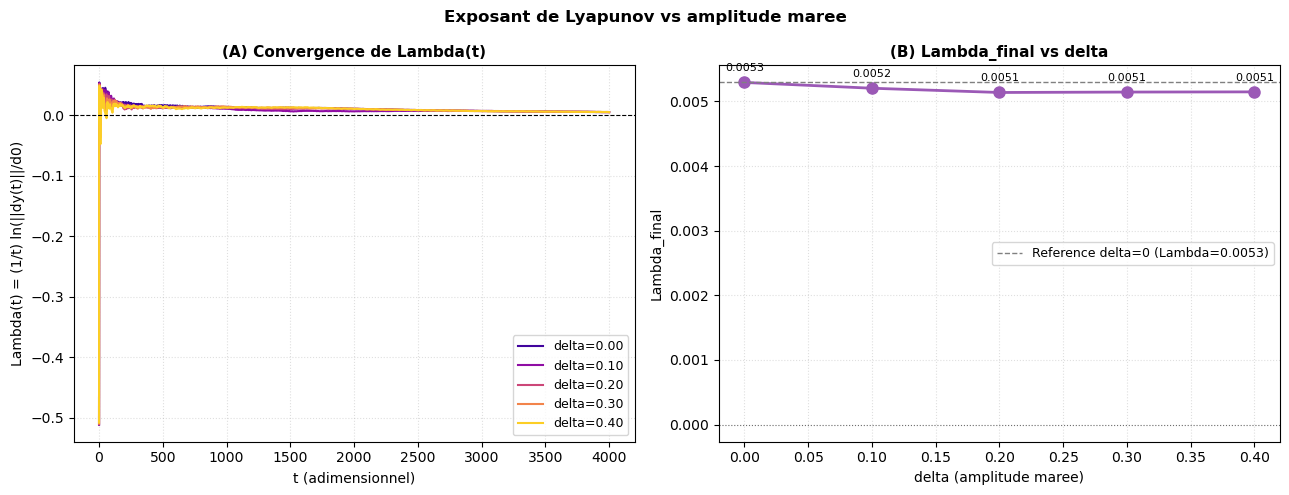

Figure → nb9_lyapunov_vs_delta.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Lyapunov exponent vs amplitude maree',
             fontsize=12, fontweight='bold')

colors_lya = plt.cm.plasma(np.linspace(0.1, 0.9, len(DELTA_LYA)))

# ── (A) Convergence Λ(t) ────────────────────────────────────────────────────
ax = axes[0]
for delta, color in zip(DELTA_LYA, colors_lya):
    t_l = lya_results[delta]['t']
    L_l = lya_results[delta]['Lambda']
    ax.plot(t_l, L_l, lw=1.5, color=color, label=f'delta={delta:.2f}')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('t (non-dimensional)', fontsize=10)
ax.set_ylabel('Lambda(t) = (1/t) ln(||dy(t)||/d0)', fontsize=10)
ax.set_title('(A) Convergence de Lambda(t)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, ls=':', alpha=0.4)

# ── (B) Λ_final vs δ ────────────────────────────────────────────────────────
ax = axes[1]
lya_finals = [lya_results[d]['Lambda_final'] for d in DELTA_LYA]
ax.plot(DELTA_LYA, lya_finals, 'o-', color='#9B59B6', lw=2, ms=8)
ax.axhline(lya_finals[0], color='gray', ls='--', lw=1,
           label=f'Reference delta=0 (Lambda={lya_finals[0]:.4f})')
ax.axhline(0, color='black', lw=0.8, ls=':', alpha=0.5)
ax.set_xlabel('delta (amplitude maree)', fontsize=10)
ax.set_ylabel('Lambda_final', fontsize=10)
ax.set_title('(B) Lambda_final vs delta', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, ls=':', alpha=0.4)
# Annoter les valeurs
for d, l in zip(DELTA_LYA, lya_finals):
    ax.annotate(f'{l:.4f}', (d, l), textcoords='offset points',
                xytext=(0, 8), fontsize=8, ha='center')

plt.tight_layout()
plt.savefig('nb9_lyapunov_vs_delta.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure → nb9_lyapunov_vs_delta.png")

---
## 7 — Distributions des intervalles de récurrence

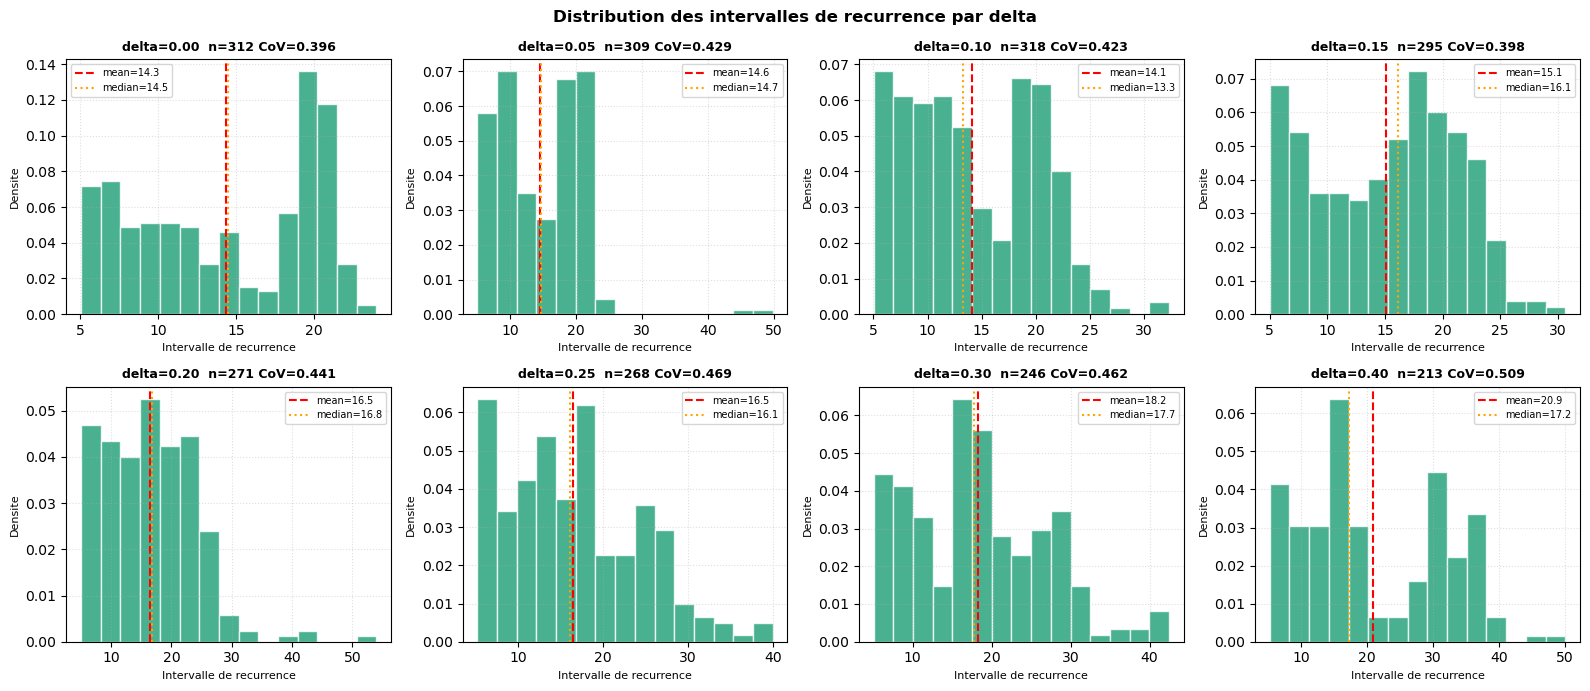

Figure → nb9_intervals.png


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
fig.suptitle('Distribution des intervalles de recurrence par delta',
             fontsize=12, fontweight='bold')

for i, delta in enumerate(DELTA_LIST):
    ax  = axes[i//4, i%4]
    ints = summary[delta]['intervals']
    CoV  = summary[delta]['CoV']
    n    = summary[delta]['n']

    if len(ints) > 0:
        ax.hist(ints, bins=15, color='#1D9E75', edgecolor='white',
                alpha=0.8, density=True)
        ax.axvline(np.mean(ints), color='red', lw=1.5, ls='--',
                   label=f'mean={np.mean(ints):.1f}')
        ax.axvline(np.median(ints), color='orange', lw=1.5, ls=':',
                   label=f'median={np.median(ints):.1f}')
    ax.set_title(f'delta={delta:.2f}  n={n} CoV={CoV:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Intervalle de recurrence', fontsize=8)
    ax.set_ylabel('Densite', fontsize=8)
    ax.legend(fontsize=7); ax.grid(True, ls=':', alpha=0.4)

plt.tight_layout()
plt.savefig('nb9_intervals.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure → nb9_intervals.png")

---
## 8 — Grille d'interprétation

### Périodicité (panneaux A, B, fig. intervals)
| CoV(δ) vs CoV(0) | Interprétation |
|---|---|
| CoV augmente avec δ | La marée **déstabilise** le cycle → moins périodique |
| CoV diminue avec δ | La marée **synchronise** le cycle → plus régulier |
| CoV non-monotone | Régimes complexes (verrouillage de phase possible) |

### Corrélation marée/sismicité (panneaux C, D, roses)
| R, p-value | Interprétation |
|---|---|
| R > 0, p < 0.05 | **Préférence de phase significative** |
| Mean phase ≈ 270° | Événements préférés au minimum de σ_n — cohérent avec Coulomb |
| Mean phase ≈ 90° | Événements au maximum de σ_n — surprenant, mérite explication |
| p > 0.05 | Distribution compatible avec l'uniformité |

### Émergence du chaos (fig. Lyapunov)
| Λ(δ) vs Λ(0) | Interprétation |
|---|---|
| Λ augmente avec δ | Le forçage **amplifie le chaos** |
| Λ constant | Le chaos est robuste, indépendant de la marée |
| Λ diminue | Le forçage **réduit le chaos** (peu probable ici) |
| Λ < 0 | Le système devient **périodique** sous forçage (phase-locking) |

**Note sur T_tide/T_rec ≈ 0.5 :** la marée oscille 2× plus vite que le cycle sismique naturel.
Pour observer du phase-locking (Arnold tongues), il faudrait tester T_tide ≈ T_rec et T_tide ≈ 2·T_rec.